### Cell 1: Imports and connect to MongoDB

In [1]:
import sys
sys.path.append("..")  # so we can import from src/ (notebook is inside notebooks/)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, db

sns.set_style("whitegrid")
%matplotlib inline

### Cell 2: Load data from MongoDB into a DataFrame

In [3]:
client = db.get_client()
collection = db.get_collection(config.FEATURES_COLLECTION, client)

# Pull every document for our city, sorted by time
cursor = collection.find({"city": config.CITY_NAME}).sort("timestamp", 1)
df = pd.DataFrame(list(cursor))

client.close()

print(df.shape)
df.head()

(17544, 23)


,_id,city,hour_bucket,aqi,aqi_change_rate,co,day,day_of_week,hour,humidity,...,nh3,no2,o3,pm10,pm2_5,pressure,so2,temperature,timestamp,wind_speed
0,6a69aad1695b3f76fa3e80df,Mithi,2024-07-29 00:00:00,88,0,113.0,29,0,0,89,...,None,3.0,42.0,103.4,20.7,990.9,5.2,28.0,2024-07-29 00:00:00,11.8
1,6a69aad1695b3f76fa3e80e0,Mithi,2024-07-29 01:00:00,89,1,113.0,29,0,1,88,...,None,2.9,42.0,104.5,20.5,991.4,5.4,28.5,2024-07-29 01:00:00,6.6
2,6a69aad1695b3f76fa3e80e1,Mithi,2024-07-29 02:00:00,90,1,114.0,29,0,2,86,...,None,2.8,43.0,110.8,20.9,992.2,5.6,28.9,2024-07-29 02:00:00,8.8
3,6a69aad1695b3f76fa3e80e2,Mithi,2024-07-29 03:00:00,91,1,115.0,29,0,3,85,...,None,2.5,46.0,109.9,21.4,992.8,5.4,29.2,2024-07-29 03:00:00,8.2
4,6a69aad1695b3f76fa3e80e3,Mithi,2024-07-29 04:00:00,91,0,117.0,29,0,4,88,...,None,2.0,53.0,117.6,24.0,993.7,4.5,28.9,2024-07-29 04:00:00,12.0


### Cell 3: Check for missing values

In [4]:
df.isnull().sum().sort_values(ascending=False)

nh3                17544
city                   0
_id                    0
aqi                    0
aqi_change_rate        0
co                     0
hour_bucket            0
day                    0
day_of_week            0
humidity               0
hour                   0
lat                    0
lon                    0
month                  0
no2                    0
o3                     0
pm10                   0
pm2_5                  0
pressure               0
so2                    0
temperature            0
timestamp              0
wind_speed             0
dtype: int64

### Cell 4: Drop the useless column

In [5]:
df = df.drop(columns=["nh3", "_id"])
df.columns.tolist()

['city',
 'hour_bucket',
 'aqi',
 'aqi_change_rate',
 'co',
 'day',
 'day_of_week',
 'hour',
 'humidity',
 'lat',
 'lon',
 'month',
 'no2',
 'o3',
 'pm10',
 'pm2_5',
 'pressure',
 'so2',
 'temperature',
 'timestamp',
 'wind_speed']

### Cell 5: Summary statistics

In [6]:
df.describe()

,hour_bucket,aqi,aqi_change_rate,co,day,day_of_week,hour,humidity,lat,lon,month,no2,o3,pm10,pm2_5,pressure,so2,temperature,timestamp,wind_speed
count,17544,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.00,1.754400e+04,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544,17544.000000
mean,2025-07-29 11:30:00,73.103511,-0.002451,186.184052,15.738714,2.991792,11.500000,52.948757,24.74,6.980000e+01,6.526676,1.698638,78.308368,54.200958,20.323552,1003.762477,3.693531,27.374761,2025-07-29 11:30:00,13.453517
min,2024-07-29 00:00:00,21.000000,-25.000000,82.000000,1.000000,0.000000,0.000000,4.000000,24.74,6.980000e+01,1.000000,0.000000,19.000000,0.100000,0.100000,986.700000,0.300000,5.900000,2024-07-29 00:00:00,0.200000
25%,2025-01-27 17:45:00,60.000000,-1.000000,114.000000,8.000000,1.000000,5.750000,33.000000,24.74,6.980000e+01,4.000000,0.600000,57.000000,22.300000,12.600000,998.475000,1.700000,23.300000,2025-01-27 17:45:00,8.600000
50%,2025-07-29 11:30:00,69.000000,0.000000,158.000000,16.000000,3.000000,11.500000,52.000000,24.74,6.980000e+01,7.000000,1.400000,72.000000,36.900000,17.800000,1003.700000,2.900000,27.900000,2025-07-29 11:30:00,13.000000
75%,2026-01-28 05:15:00,82.000000,0.000000,233.000000,23.000000,5.000000,17.250000,73.000000,24.74,6.980000e+01,10.000000,2.400000,97.000000,67.800000,25.400000,1009.300000,4.900000,32.100000,2026-01-28 05:15:00,17.800000
max,2026-07-29 23:00:00,203.000000,35.000000,846.000000,31.000000,6.000000,23.000000,100.000000,24.74,6.980000e+01,12.000000,13.800000,161.000000,478.700000,105.200000,1019.900000,23.400000,45.500000,2026-07-29 23:00:00,42.700000
std,NaN,20.831504,2.595021,94.156836,8.804172,2.000724,6.922384,23.990513,0.00,1.421126e-14,3.445635,1.378561,27.536466,50.301056,11.525767,6.550765,2.739856,7.196904,NaN,6.415496


### Cell 6: Plot AQI over time

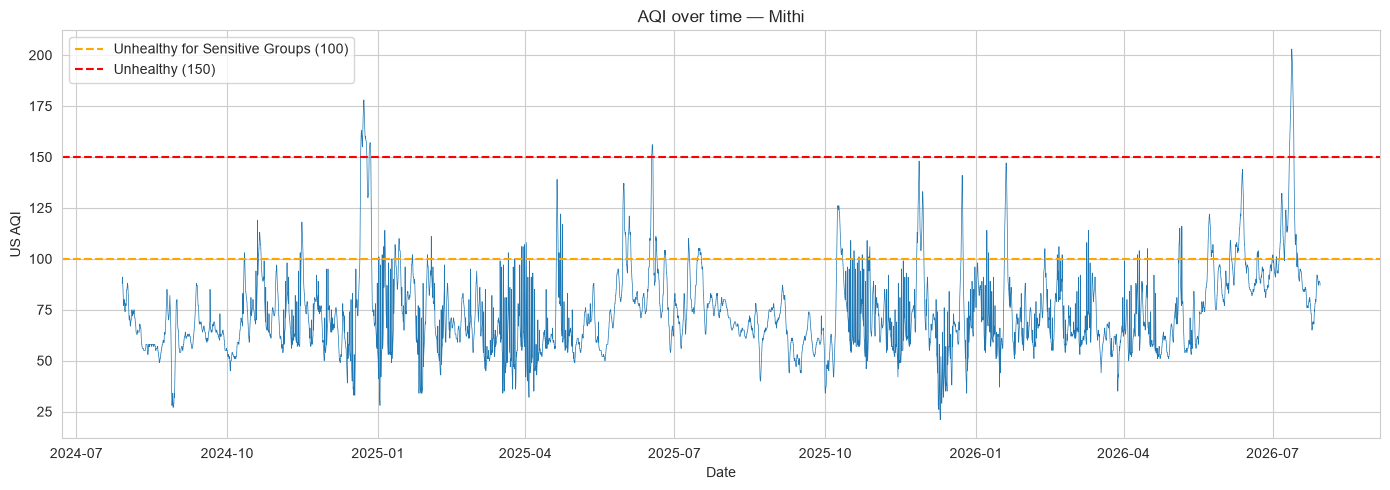

In [7]:
plt.figure(figsize=(14, 5))
plt.plot(df["timestamp"], df["aqi"], linewidth=0.5)
plt.title(f"AQI over time — {config.CITY_NAME}")
plt.xlabel("Date")
plt.ylabel("US AQI")
plt.axhline(y=100, color="orange", linestyle="--", label="Unhealthy for Sensitive Groups (100)")
plt.axhline(y=150, color="red", linestyle="--", label="Unhealthy (150)")
plt.legend()
plt.tight_layout()
plt.show()

### Cell 7: AQI distribution by month

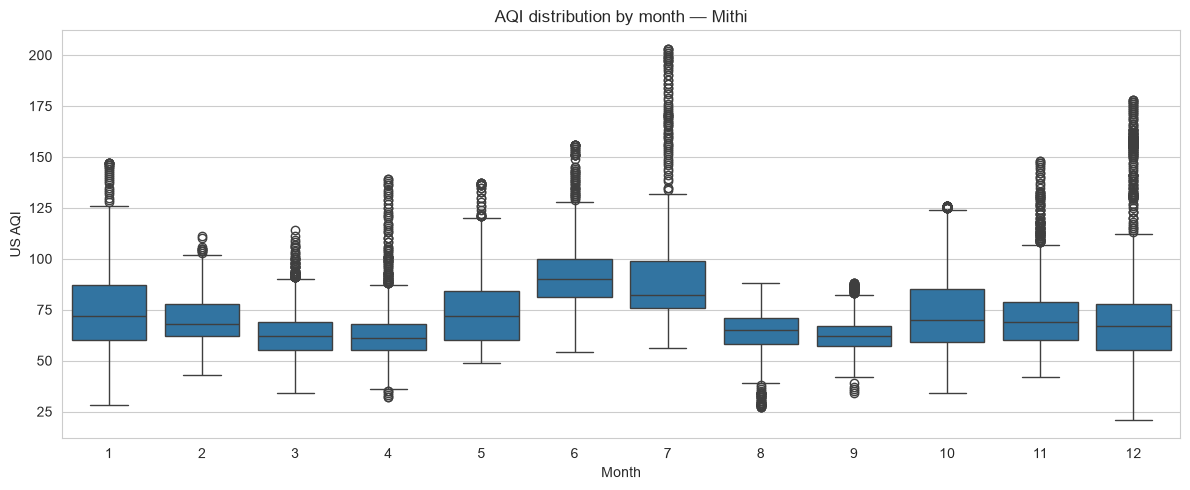

In [8]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="month", y="aqi")
plt.title(f"AQI distribution by month — {config.CITY_NAME}")
plt.xlabel("Month")
plt.ylabel("US AQI")
plt.tight_layout()
plt.show()

### Cell 8: Look at the most extreme rows

In [9]:
df.nlargest(10, "aqi")[["timestamp", "aqi", "pm2_5", "pm10", "co"]]

,timestamp,aqi,pm2_5,pm10,co
17126,2026-07-12 14:00:00,203,67.3,380.9,86.0
17127,2026-07-12 15:00:00,203,65.0,362.3,86.0
17128,2026-07-12 16:00:00,203,62.4,344.6,86.0
17129,2026-07-12 17:00:00,202,61.7,338.1,87.0
17125,2026-07-12 13:00:00,201,67.8,389.3,87.0
17130,2026-07-12 18:00:00,201,61.0,326.9,87.0
17131,2026-07-12 19:00:00,200,57.9,305.5,86.0
17124,2026-07-12 12:00:00,199,72.4,418.2,87.0
17132,2026-07-12 20:00:00,199,53.7,284.1,85.0
17133,2026-07-12 21:00:00,199,51.9,275.7,84.0


### Cell 9: Correlation heatmap

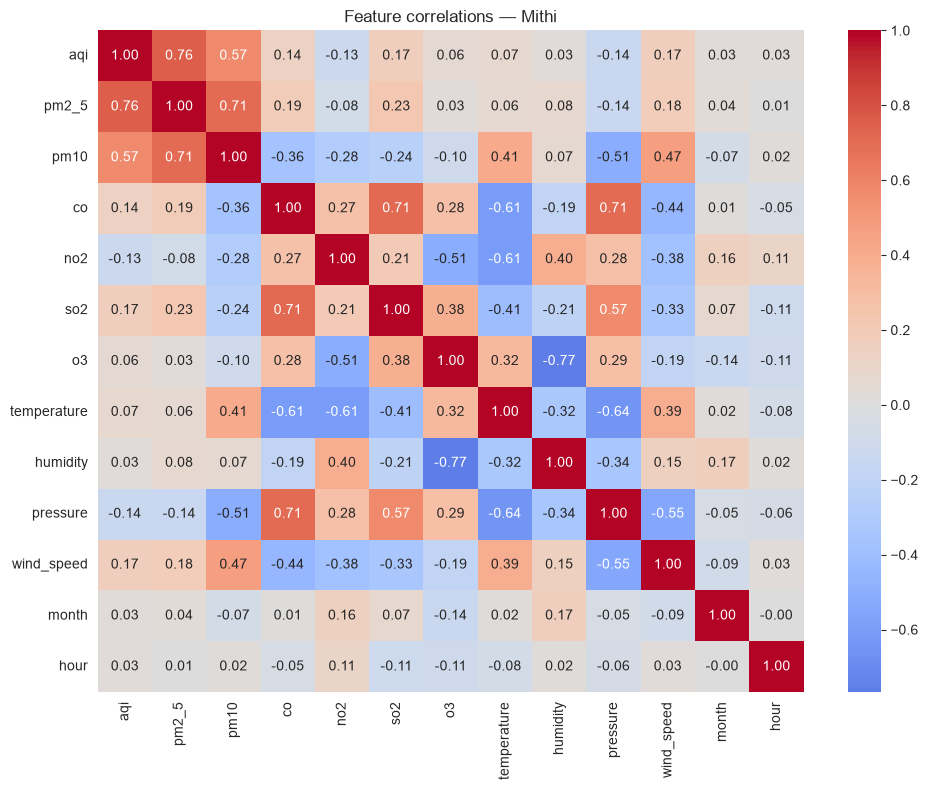

In [10]:
numeric_cols = ["aqi", "pm2_5", "pm10", "co", "no2", "so2", "o3",
                 "temperature", "humidity", "pressure", "wind_speed", "month", "hour"]

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title(f"Feature correlations — {config.CITY_NAME}")
plt.tight_layout()
plt.show()

### Cell 10: AQI by hour of day

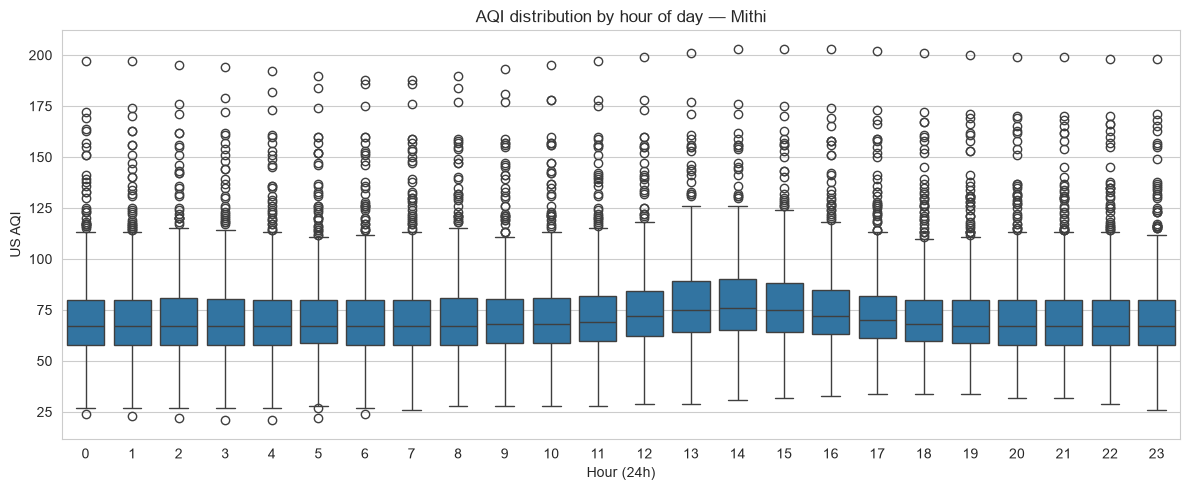

In [11]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="hour", y="aqi")
plt.title(f"AQI distribution by hour of day — {config.CITY_NAME}")
plt.xlabel("Hour (24h)")
plt.ylabel("US AQI")
plt.tight_layout()
plt.show()